# Data Exploration and Visual Exploration Lab

In this lab, you will practice an exploratory workflow using a PM2.5 air-quality dataset from North Carolina.

This lab comes after the lessons on **Data Exploration** and **Visual Data Exploration**. The goal is not just to run code, but to decide what to inspect, interpret what you find, and document your reasoning.

## Learning goals

By the end of this lab, you should be able to:

- Load a CSV file into a Pandas dataframe.
- Inspect dataframe structure, column names, data types, and missing values.
- Explore numeric, categorical, and datetime fields.
- Summarize a numeric variable using descriptive statistics.
- Create exploratory visualizations using Pandas plotting methods.
- Compare plot types and choose appropriate visual tools for different questions.
- Write short interpretations of exploratory results.


## Part 1: Set Up the Session

Load the packages and define the folder paths used in this course project.


In [65]:
# Import packages: Path (from pathlib) and Pandas (as pd)
from pathlib import Path
import pandas as pd


In [15]:
# Set folder paths: project, raw, and processed
root_fldr = Path.cwd().parent.parent
raw_fldr = root_fldr/ 'data'/ 'raw'
processed_fldr = root_fldr /'data' / 'processed'

print(root_fldr)
print(raw_fldr)
print(processed_fldr)

#project_fldr = Path.cwd().parent.parent  # lessons/M3 → lessons → ENV700
#raw_fldr = project_fldr / "data" / "raw"
#processed_fldr = project_fldr / "data" / "processed"

/Users/matthewswire/Desktop/Duke/Fall_2026/Data_Exploration/ENV700
/Users/matthewswire/Desktop/Duke/Fall_2026/Data_Exploration/ENV700/data/raw
/Users/matthewswire/Desktop/Duke/Fall_2026/Data_Exploration/ENV700/data/processed


## Part 2: Load the Data
Read `EPAair_PM25_NC2025_raw.csv` into a dataframe named `pm25`.

When reading the file:

- Set `Site ID` to use the `category` data type.
- Parse `Date` as a datetime field.
- Use the date format `%m/%d/%Y`.

>Tip: See section 9 in the **M3-1** notebook.

In [149]:
pm25_test = pd.read_csv(
    raw_file,
    dtype={"Site ID": "category"},
    parse_dates=["Date"],
    date_format='%m/%d/%Y'
)
print(pm25_test['Date'].dtype)

str


In [156]:
# Read the CSV file into a dataframe named pm25.
raw_file = raw_fldr / "EPAair_PM25_NC2025_raw.csv"

pm25 = pd.read_csv(
    raw_file,
    dtype={
        "Site ID": "category"
        },
    parse_dates=["Date"],
)


pm25['Date'] = pd.to_datetime(pm25['Date'], format='%m/%d/%Y')

pm25['Date'].head()



/var/folders/bn/xb4trjw94ys5nm79l1gkm1zr0000gn/T/ipykernel_46586/3075222811.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pm25 = pd.read_csv(


0   2025-01-01
1   2025-01-04
2   2025-01-07
3   2025-01-10
4   2025-01-13
Name: Date, dtype: datetime64[us]

In [26]:
# Display the first few rows.
pm25.head()

,Date,Source,Site ID,POC,Daily Mean PM2.5 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,Method Code,Method Description,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2025,AQS,370110002,1,0.7,ug/m3 LC,4,Linville Falls,1,100.0,...,707.0,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,NaN,NaN,37,North Carolina,11,Avery,35.972347,-81.933072
1,01/04/2025,AQS,370110002,1,1.2,ug/m3 LC,7,Linville Falls,1,100.0,...,707.0,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,NaN,NaN,37,North Carolina,11,Avery,35.972347,-81.933072
2,01/07/2025,AQS,370110002,1,1.5,ug/m3 LC,8,Linville Falls,1,100.0,...,707.0,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,NaN,NaN,37,North Carolina,11,Avery,35.972347,-81.933072
3,01/10/2025,AQS,370110002,1,4.2,ug/m3 LC,23,Linville Falls,1,100.0,...,707.0,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,NaN,NaN,37,North Carolina,11,Avery,35.972347,-81.933072
4,01/13/2025,AQS,370110002,1,5.0,ug/m3 LC,28,Linville Falls,1,100.0,...,707.0,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,NaN,NaN,37,North Carolina,11,Avery,35.972347,-81.933072


### Reflection

In one or two sentences, describe what a single row in this dataset appears to represent.

**Your answer:**


## Part 3: Inspect the Dataframe Structure

Use dataframe attributes and methods to answer the following questions.

- How many rows and columns are in the dataframe?
- What are the column names?
- What data type is assigned to each column?
- Which columns are numeric?
- Which columns are categorical or text-like?
- Which column is datetime?


In [40]:
# How many rows and columns are in the dataframe?
pm25.shape

(10184, 22)

In [41]:
# What are the column names?
pm25.columns

Index(['Date', 'Source', 'Site ID', 'POC', 'Daily Mean PM2.5 Concentration',
       'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count',
       'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description',
       'Method Code', 'Method Description', 'CBSA Code', 'CBSA Name',
       'State FIPS Code', 'State', 'County FIPS Code', 'County',
       'Site Latitude', 'Site Longitude'],
      dtype='str')

In [89]:
# Display data types and non-null counts for all the columns?

pm25.info



<bound method DataFrame.info of            Date Source    Site ID  POC  Daily Mean PM2.5 Concentration  \
0        1/1/25    AQS  370110002    1                             0.7   
1        1/4/25    AQS  370110002    1                             1.2   
2        1/7/25    AQS  370110002    1                             1.5   
3       1/10/25    AQS  370110002    1                             4.2   
4       1/13/25    AQS  370110002    1                             5.0   
...         ...    ...        ...  ...                             ...   
10179  12/27/25    AQS  371830021    3                             8.9   
10180  12/28/25    AQS  371830021    3                             4.7   
10181  12/29/25    AQS  371830021    3                             5.2   
10182  12/30/25    AQS  371830021    3                             4.2   
10183  12/31/25    AQS  371830021    3                             4.4   

          Units  Daily AQI Value Local Site Name  Daily Obs Count  \
0      ug/

### Interpretation

Answer the following based on the output above.

1. How many observations are in the dataset?  10184
2. How many variables are in the dataset?  22
3. Which variable uses a datetime data type?  'Date' which is the first column 
4. Why should `Site ID` be stored as a category instead of as a number? There is a repetition for the data for each site which we'd want to track over time 

**Your answers:**
1. 10184
2. 22
3. 'Date' which is the first column 
4. There is a repetition for the data for each site which we'd want to track over time 


## Part 4: Check for Missing Values

Missing values are important to identify early because they can affect summaries, plots, and later analysis.


In [ ]:
# Count missing values in each column.

missing_data = pm25.isna().sum()


missing_data

Date                                 0
Source                               0
Site ID                              0
POC                                  0
Daily Mean PM2.5 Concentration       0
Units                                0
Daily AQI Value                      0
Local Site Name                      0
Daily Obs Count                      0
Percent Complete                     0
AQS Parameter Code                   0
AQS Parameter Description            0
Method Code                         56
Method Description                  56
CBSA Code                         1500
CBSA Name                         1500
State FIPS Code                      0
State                                0
County FIPS Code                     0
County                               0
Site Latitude                        0
Site Longitude                       0
dtype: int64

In [101]:
#note that the opposite would be utilizing 'notna' instead of isna

data_present = pm25.notna().sum()

data_present

Date                              10184
Source                            10184
Site ID                           10184
POC                               10184
Daily Mean PM2.5 Concentration    10184
Units                             10184
Daily AQI Value                   10184
Local Site Name                   10184
Daily Obs Count                   10184
Percent Complete                  10184
AQS Parameter Code                10184
AQS Parameter Description         10184
Method Code                       10128
Method Description                10128
CBSA Code                          8684
CBSA Name                          8684
State FIPS Code                   10184
State                             10184
County FIPS Code                  10184
County                            10184
Site Latitude                     10184
Site Longitude                    10184
dtype: int64

In [97]:
# Optional: Calculate the percentage of records missing in each column.
# Hint: divide the missing-value counts by the number of rows and multiply by 100.

# Your code here



# Calculate the percentage of missing values by column
missing_percent = (pm25.isna().mean().sort_values(ascending=False) * 100).round(2)

missing_percent


CBSA Name                         14.73
CBSA Code                         14.73
Method Description                 0.55
Method Code                        0.55
Date                               0.00
Source                             0.00
Site Latitude                      0.00
County                             0.00
County FIPS Code                   0.00
State                              0.00
State FIPS Code                    0.00
AQS Parameter Description          0.00
AQS Parameter Code                 0.00
Percent Complete                   0.00
Daily Obs Count                    0.00
Local Site Name                    0.00
Daily AQI Value                    0.00
Units                              0.00
Daily Mean PM2.5 Concentration     0.00
POC                                0.00
Site ID                            0.00
Site Longitude                     0.00
dtype: float64

### Interpretation

1. Which columns, if any, contain missing values?  
2. Are the missing values likely to affect the initial exploration? Why or why not?  

**Your answers:**
1. CBSA Name and Codes well as the method description + code
2. This will inhibit further compliance to assess if the plant in question is following the standard. Perhaps these are outside of certain jurisdictions or their is manual error that forgot to add this information to the monitoring data

## Part 5: Explore a Numeric Variable

The main numeric variable in this dataset is daily mean PM2.5 concentration.

Use the column:

```python
"Daily Mean PM2.5 Concentration"
```


In [118]:
# Store the concentration column name in a shorter variable for reuse.
daily_conc = "Daily Mean PM2.5 Concentration"



In [119]:
# Display descriptive statistics for daily mean PM2.5 concentration.

pm25.describe().round(2)


,POC,Daily Mean PM2.5 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
count,10184.00,10184.00,10184.00,10184.0,10184.0,10184.00,10128.00,8684.00,10184.0,10184.00,10184.00,10184.00
mean,3.10,7.10,36.88,1.0,100.0,88125.06,306.68,30651.45,37.0,100.34,35.61,-80.03
std,0.85,3.70,15.15,0.0,0.0,95.23,195.00,13480.76,0.0,49.69,0.47,1.76
min,1.00,-1.80,0.00,1.0,100.0,88101.00,145.00,11700.00,37.0,11.00,34.36,-83.44
25%,3.00,4.50,25.00,1.0,100.0,88101.00,209.00,16740.00,37.0,63.00,35.28,-81.37
50%,3.00,6.50,36.00,1.0,100.0,88101.00,209.00,25860.00,37.0,119.00,35.64,-80.22
75%,3.00,9.02,50.25,1.0,100.0,88101.00,209.00,40580.00,37.0,129.00,35.99,-78.57
max,5.00,43.70,121.00,1.0,100.0,88502.00,707.00,49180.00,37.0,183.00,36.51,-76.21


In [ ]:
# Compute the mean and median separately.
mean_pm25 = pm25[daily_conc].mean()
median_pm25 = pm25[daily_conc].median()

Mean PM2.5: 7.097839748625294


In [126]:
# Print the values
mean_pm25 = pm25[daily_conc].mean()
median_pm25 = pm25[daily_conc].median()
print("Mean PM2.5:", mean_pm25.round(2),'Median PM2.5:', median_pm25.round(2))

Mean PM2.5: 7.1 Median PM2.5: 6.5


* Use the [quantiles](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.quantile.html) method to display the quantiles of the dataframe. Adjust the command to show the highest and lowest 20th percentile (4.1 and 9.7, respectively).

In [128]:
# Compute selected quantiles.
pm25[daily_conc].quantile([0.2, 0.80,])

0.2    4.1
0.8    9.7
Name: Daily Mean PM2.5 Concentration, dtype: float64

### Interpretation

1. What is the minimum daily mean PM2.5 concentration?  
2. What is the maximum daily mean PM2.5 concentration?  
3. Is the mean larger or smaller than the median?  
4. What might the relationship between the mean and median suggest about the shape of the distribution?  
5. In what units are PM2.5 concentrations reported?  

**Your answers:**
1. -1.8 
2. 43.7 
3. Mean is larger at 7.1 vs 6.5 for the mdian 
4. There could potential be some large outliers which are skewing the data up from the median evident in the high maximmum of 43.7 which likely had an outsized impact on the mean 
5. micrograms per cubic meter (μg/m³) 


## Part 6: Explore Categorical Variables

Categorical variables often describe groups, locations, sources, or measurement types.

Start with `Site ID` and `County`.


In [135]:
# How many unique monitoring sites are included?
print('Number of unique Site IDs:',pm25['Site ID'].nunique())



Number of unique Site IDs: 26


In [136]:
# List the unique Site ID categories?
print('Unique Site IDs:',pm25['Site ID'].unique())




Unique Site IDs: ['370110002', '370210034', '370350004', '370510009', '370570002', ..., '371590021', '371730002', '371730007', '371830014', '371830021']
Length: 26
Categories (26, str): ['370110002', '370210034', '370350004', '370510009', ..., '371730002', '371730007', '371830014', '371830021']


In [142]:
# Count records by county.

pm25['County'].value_counts()



County
Mecklenburg    1226
Forsyth         895
Wake            840
Buncombe        762
New Hanover     709
Catawba         695
Swain           614
Durham          585
Davidson        398
Pitt            362
Guilford        360
Mitchell        359
Edgecombe       358
Cumberland      357
Montgomery      354
Northampton     353
Johnston        352
Rowan           352
Avery            87
Hyde             86
Haywood          80
Name: count, dtype: int64

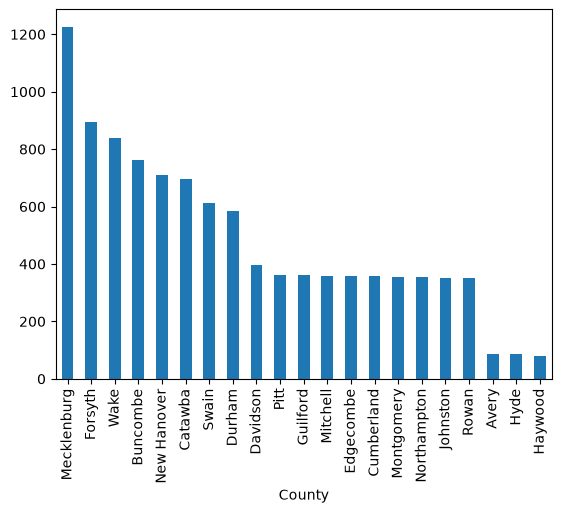

In [139]:
# Create a simple bar plot showing the number of records by county.
# Hint: combine value_counts() with Pandas .plot(kind='bar').

pm25['County'].value_counts().plot(kind='bar');



### Interpretation

1. How many different monitoring sites are included?  
2. Which source contributes the most observations?  
3. Are observations balanced across sources?  
4. Why might an unbalanced number of observations matter when comparing groups?  

**Your answers:**
1. The full data set of ~10,000
2. Mecklenburg
3. Not a clear spread
4. Perhaps there are more sites within a polluting sites in a county which results in great number of observations being made there 


## Part 7: Explore the Datetime Field

Datetime fields have useful sub-components such as year, month, day, and day of week.


In [ ]:
# What date range is covered by the dataset? Print the earliest and latest dates in the dataset
pm25['year'] = pm25['Date'].dt.year
pm25['day'] = pm25['Date'].dt.date

pm25['Date'].describe()

print('Earliest date:',pm25['day'].min())
print('Latest date',pm25['day'].max())




Earliest date: 2025-01-01
Latest date 2025-12-31


In [182]:
# Count observations by month.
pm25['month'] = pm25['Date'].dt.month

observations_per_month = pm25['month'].value_counts(sort=False)

observations_per_month


month
1     856
2     751
3     837
4     825
5     888
6     861
7     896
8     908
9     850
10    793
11    851
12    868
Name: count, dtype: int64

In [ ]:
# Optional: Create a month column for later exploration.

pm25['month'] = pm25['Date'].dt.month


### Interpretation

1. What time period is covered by this dataset?  
2. Does the dataset appear to cover a full calendar year?  
3. Are observations evenly distributed across months?  

**Your answers:**
1. An in-depth analysis of 2025
2. Just covers 2025 
3. They are with less observations present in days with fewer days (e.g. February)


## Part 8: Visualize the Distribution of PM2.5

Start by visualizing the distribution of daily mean PM2.5 concentrations.


"#Histogram of mean discharge values\nUSGS_flow_data['discharge_mean'].plot(\n    kind='hist',\n    xlim=(0,5000),\n    bins = 50,\n    logy= True,\n    figsize= (10,4), #figuresize for graph\n    width = 100, #for width of bars\n    grid = True #adds a grid to the graph\n)"

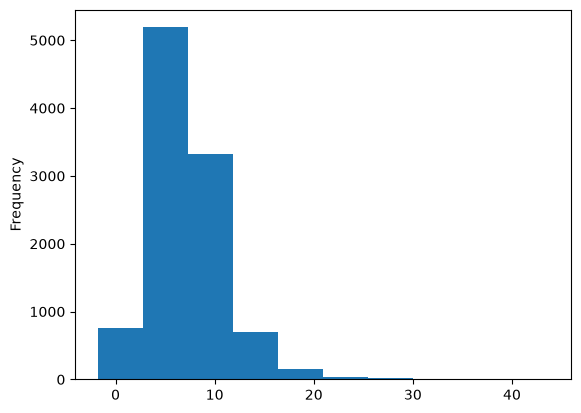

In [ ]:
# Create a histogram of daily mean PM2.5 concentration using Pandas plotting.
# Hint: select the concentration Series and use .plot(kind='hist').

pm25['Daily Mean PM2.5 Concentration'].plot(kind = 'hist')


<Axes: >

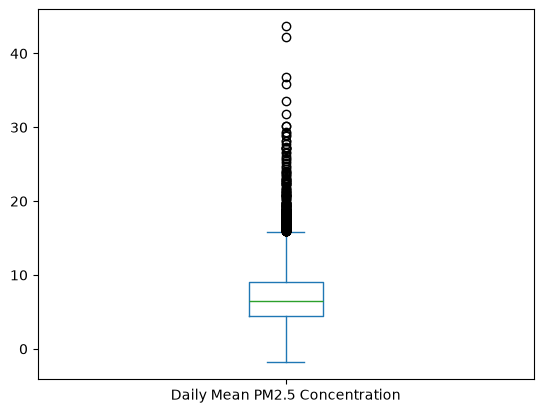

In [184]:
# Create a box plot of daily mean PM2.5 concentration using Pandas plotting.
# Hint: select the concentration Series and use .plot(kind='box').

pm25['Daily Mean PM2.5 Concentration'].plot(kind = 'box')


### Interpretation

1. Is the distribution symmetric, left-skewed, or right-skewed?  
2. Are there possible outliers?  
3. Which plot made it easier to see the overall shape of the distribution?  
4. Which plot made it easier to identify unusually high values?  

**Your answers:**
1. There is a right-skewed distribution with a larger tail go to higher quantities of average daily pollution
2. There are quite a few outliers above the 95% cofidence interval resulting in this skew 
3. I think the box plot 
4. The box plot 

## Part 9: Compare PM2.5 by Source

Now compare daily mean PM2.5 concentration across measurement sources.

Create several visualizations, then decide which one is most useful for comparison.

>Below is code to transform the data such that concentration values are separated into different columns based on their source type ("AQS" or "AirNow"). We'll examine this code later, but you will need this format to produce the KDE plot.

In [224]:
#Transform data so concentration values are in separate columns by Source
pm25_wide = pm25.pivot_table(
    index = ['Site ID','Date'],
    columns = 'Source',
    values = daily_conc,
    aggfunc = 'mean'
).reset_index()

#Show the data
pm25_wide.tail()

Source,Site ID,Date,AQS,AirNow
8344,371830021,2025-12-27,8.9,NaN
8345,371830021,2025-12-28,4.7,NaN
8346,371830021,2025-12-29,5.2,NaN
8347,371830021,2025-12-30,4.2,NaN
8348,371830021,2025-12-31,4.4,NaN


<Axes: ylabel='Density'>

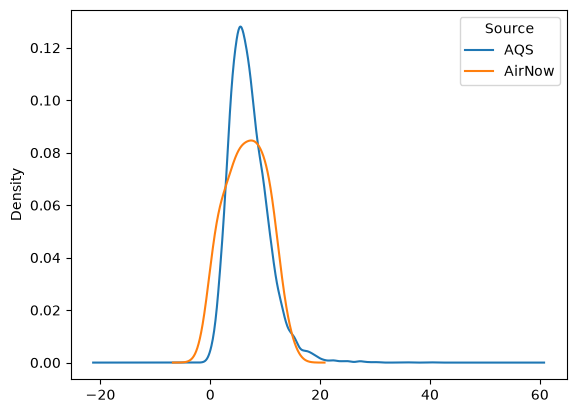

In [223]:
# Create overlaid density (KDE) curves comparing PM2.5 concentration by source. 
# Use Pandas .plot(kind='kde').

pm25_wide[['AQS','AirNow']].plot(
    kind='kde')


<Axes: >

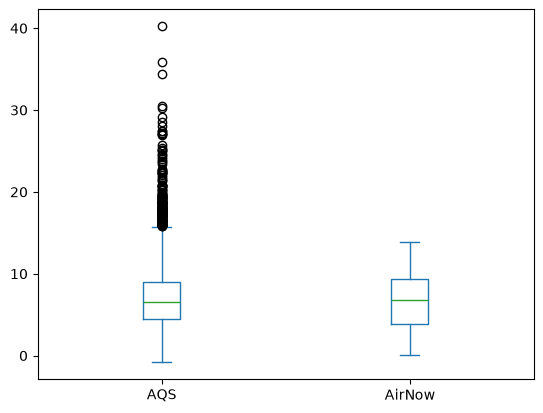

In [231]:
# Create a box plot comparing PM2.5 concentration by source.
# Hint: use Pandas .plot(kind='box', by='Source') or DataFrame.boxplot().

pm25_wide[['AQS','AirNow']].plot(
    kind='box')

array([<Axes: title={'center': 'AQS'}, ylabel='Frequency'>,
       <Axes: title={'center': 'AirNow'}, ylabel='Frequency'>],
      dtype=object)

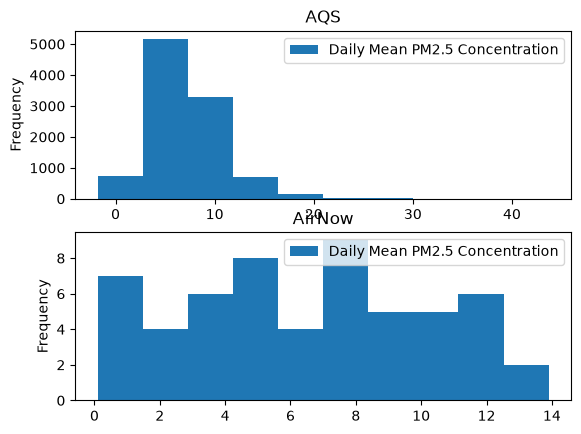

In [233]:
# Create histograms of PM2.5 concentration for each source.
# Use Pandas plotting to compare the distributions. You may create separate plots or overlay them.

pm25[[daily_conc,'Source']].plot(kind='hist',by='Source')

## Part 11: Data Exploration Checklist

Use this checklist when exploring a new dataset.

- [ ] Load the data and confirm it imported correctly.
- [ ] Examine rows, columns, and column names.
- [ ] Inspect data types.
- [ ] Identify missing values.
- [ ] Summarize numeric variables.
- [ ] Examine categorical variables.
- [ ] Explore datetime variables.
- [ ] Visualize distributions.
- [ ] Compare groups when relevant.
- [ ] Document unusual observations.
- [ ] Write short conclusions in plain language.
